In [1]:
# installations

# Install yfinance inside the JupyterLab environment
import sys
!{sys.executable} -m pip install yfinance --upgrade --use-pep517

# Installation of pandas_ta
!pip install pandas_ta

# Installation of XGBoost
!pip install xgboost
!pip install --upgrade xgboost

# Installation of Optuna
!pip install optuna

In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sn
import math
from math import sqrt

import yfinance as yf
import pandas_ta as ta

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import scipy.stats as stats
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from sklearn.feature_selection import mutual_info_regression

from sklearn.model_selection import train_test_split

import optuna

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Predicting Bitcoin Prices Using Machine Learning

## Introduction / Abstract

This project aims to predict Bitcoin’s 
price movements by combining machine learning methods like XGBoost and Random Forest. Both of these models capture different patterns in the past price data and technical indicators, helping to create a fuller picture of what might happen next. Walk-forward tuning is used to mimic how predictions would work in real time by continually updating and testing the model on new data chunks. To get the best results, I employ Optuna for smart hyperparameter tuning, which helps each model perform at its best. Together, these approaches offer a practical and reliable way to forecast Bitcoin prices, which traders and analysts can use to make better decisions. Other external factors influence BTC price a lot. This is the reason why I will subject the models to futher development so that they can take these factors into consideration, as well.

## Dataset & Preprocessing

In [3]:
# Read the Kaggle dataset containing Bitcoin historical data
# Link: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data
btc_data = pd.read_csv("data/btcusd_1-min_data.csv")

In [4]:
btc_data

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
1,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
2,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
3,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
4,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
...,...,...,...,...,...,...
7251512,1.760572e+09,110716.00,110740.00,110716.00,110740.00,6.220424
7251513,1.760572e+09,110740.00,110740.00,110716.00,110716.00,3.255152
7251514,1.760572e+09,110716.00,110717.00,110716.00,110717.00,5.158200
7251515,1.760573e+09,110716.00,110740.00,110716.00,110740.00,1.173851


In [5]:
# Convert timestamp to datetime
btc_data['Timestamp'] = pd.to_datetime(btc_data['Timestamp'], unit='s')

In [6]:
# A quick look at the data
btc_data.tail()

,Timestamp,Open,High,Low,Close,Volume
7251512,2025-10-15 23:53:00,110716.0,110740.0,110716.0,110740.0,6.220424
7251513,2025-10-15 23:54:00,110740.0,110740.0,110716.0,110716.0,3.255152
7251514,2025-10-15 23:55:00,110716.0,110717.0,110716.0,110717.0,5.158200
7251515,2025-10-15 23:56:00,110716.0,110740.0,110716.0,110740.0,1.173851
7251516,2025-10-15 23:57:00,110740.0,110763.0,110740.0,110763.0,1.370955


In [7]:
# put the date as an index
btc_data.set_index('Timestamp', inplace=True)

In [8]:
# Daily resampling
btc_data_daily = btc_data.resample('1D').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})

In [9]:
btc_data[btc_data.index.astype(str).str.startswith("2025-10-15 00:00:00")].describe()

,Open,High,Low,Close,Volume
count,1.0,1.0,1.0,1.0,1.000000
mean,113077.0,113091.0,113041.0,113081.0,0.874398
std,NaN,NaN,NaN,NaN,NaN
min,113077.0,113091.0,113041.0,113081.0,0.874398
25%,113077.0,113091.0,113041.0,113081.0,0.874398
50%,113077.0,113091.0,113041.0,113081.0,0.874398
75%,113077.0,113091.0,113041.0,113081.0,0.874398
max,113077.0,113091.0,113041.0,113081.0,0.874398


In [10]:
btc_data_daily.tail()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2025-10-11,112989.0,113444.0,109711.0,110764.0,2954.913907
2025-10-12,110769.0,115854.0,109711.0,115090.0,2969.343862
2025-10-13,115089.0,116035.0,113751.0,115265.0,1947.580681
2025-10-14,115275.0,115508.0,109971.0,113078.0,2253.667329
2025-10-15,113077.0,113655.0,110217.0,110763.0,2021.923209


In [11]:
# Shape of the daily BTC dataset
btc_data_daily.shape

(5037, 5)

Now there are much less records that is why some additional measurements will be included as features.

In [12]:
# Although the dataset seems sorted chronologically, a sorting method by the dateTime index is called to ensure everything is correct.
btc_data_daily = btc_data_daily.sort_index()

In [13]:
# Check for null values in the original set
btc_data.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [14]:
# Check for null values in the resampled dataset
btc_data_daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5037 entries, 2012-01-01 to 2025-10-15
Freq: D
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5037 non-null   float64
 1   High    5037 non-null   float64
 2   Low     5037 non-null   float64
 3   Close   5037 non-null   float64
 4   Volume  5037 non-null   float64
dtypes: float64(5)
memory usage: 236.1 KB


- There are no null values which is due to the fact that all the data has been fetched from a reliable API.
- The feature types are also appropriate.

### Columns

<b>A short description of the features (a standard stock measurement; also called OHLCV): </b>
- Open --> the price of BTC when the day started (<= High and >= Low)
- High --> the highest price of BTC in the mentioned day (the highest value for the day)
- Low --> the lowest price of BTC in the mentioned day (the lowest value for the day)
- Close --> the price of BTC when the day ended (<= High and >= Low)
- Volume --> the total amount of BTC which were traded

## EDA - Exploratory Data Analysis

In [15]:
btc_data_daily

,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01,4.58,4.84,4.58,4.84,10.000000
2012-01-02,4.84,5.00,4.84,5.00,10.100000
2012-01-03,5.00,5.32,5.00,5.29,107.085281
2012-01-04,5.29,5.57,4.93,5.57,107.233260
2012-01-05,5.57,6.46,5.57,6.42,70.328742
...,...,...,...,...,...
2025-10-11,112989.00,113444.00,109711.00,110764.00,2954.913907
2025-10-12,110769.00,115854.00,109711.00,115090.00,2969.343862
2025-10-13,115089.00,116035.00,113751.00,115265.00,1947.580681


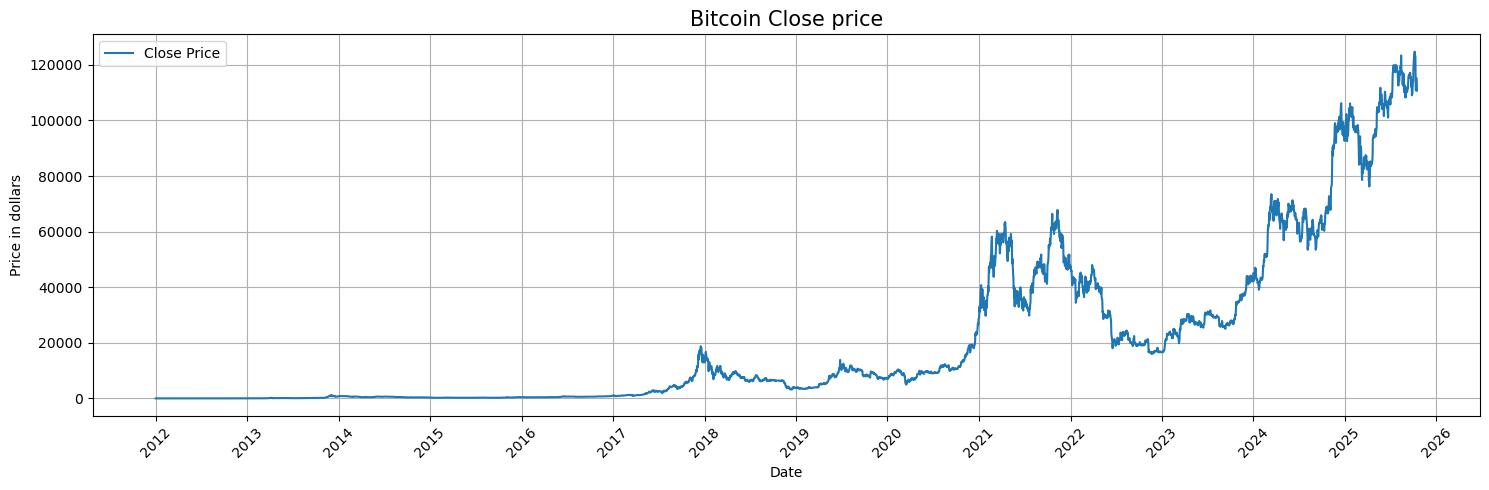

In [16]:
# Plot for visualizing the price trend
plt.figure(figsize = (15, 5))
plt.plot(btc_data_daily['Close'], label = 'Close Price')

plt.title('Bitcoin Close price', fontsize = 15)
plt.xlabel('Date')
plt.ylabel('Price in dollars')
plt.grid(True)
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

An upward trend can be noticed from this chart. BTC started with a price near the 0 in 2012 (only 4 US dollars) and nowadays it is about $120,000. According to the line chart above the steepest increase is in 2021. However, there are some dips in the price especially in 2022.

In [17]:
# Let's plot some barplots to see the details

In [18]:
btc_data_daily.describe()

,Open,High,Low,Close,Volume
count,5037.000000,5037.000000,5037.000000,5037.000000,5037.000000
mean,20514.790264,20963.849605,20047.129545,20536.673609,7426.478889
std,29044.821199,29568.147048,28495.696903,29071.074500,9025.350288
min,4.380000,4.380000,3.800000,4.380000,0.000000
25%,439.200000,449.000000,428.420000,439.860000,1983.421478
50%,7160.000000,7354.100000,6922.070000,7162.050000,4508.774920
75%,30039.900000,30505.140000,29377.000000,30047.000000,9582.988310
max,124728.000000,126272.000000,123148.000000,124728.000000,127286.486533


Conclusion from the describe method:
OHLC values range from 4 - 123+k which is a huge range. The median is approx. 7000 and it is closer to the minimum and far from the maximum. As a result, the distribution histograms are expected to be right-skewed. This means that BTC had a huge increase for a short period of time in recent years.

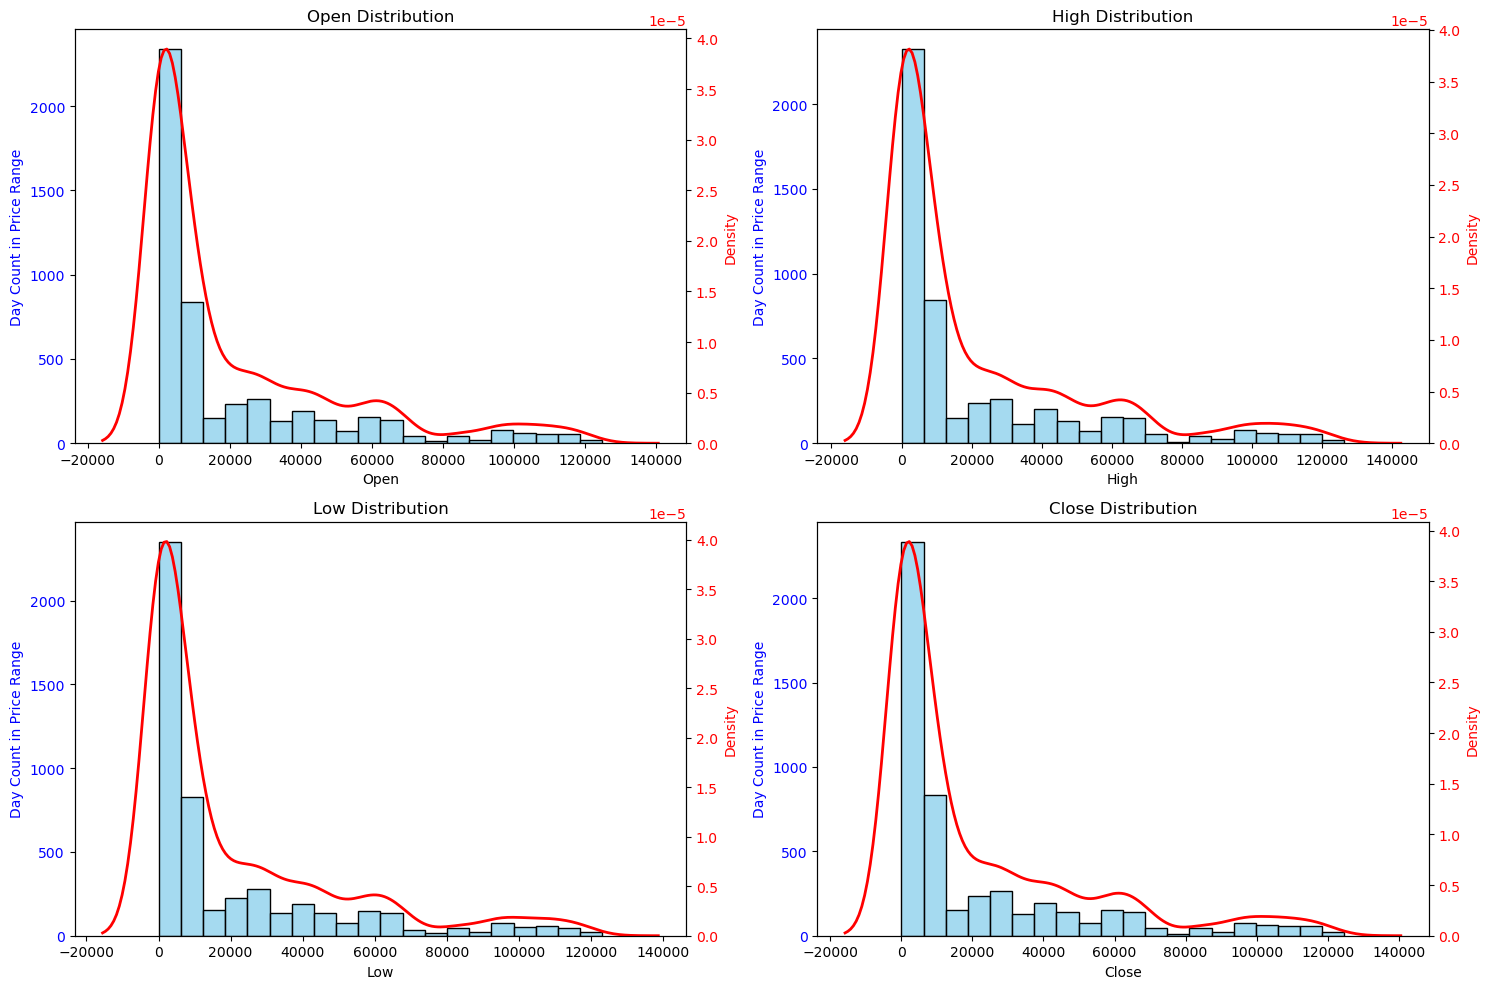

In [19]:
# Distribution of the values Open, High, Low, Close
features = ['Open', 'High', 'Low', 'Close']
fig, axes = plt.subplots(2, 2, figsize = (15, 10))
for i, col in enumerate(features):
    row = i // 2
    col_idx = i % 2
    ax1 = axes[row, col_idx]

    # Histogram on primary y-axis
    sn.histplot(btc_data_daily[col], bins=20, ax=ax1, color='skyblue')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Day Count in Price Range', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # KDE on secondary y-axis
    ax2 = ax1.twinx()
    sn.kdeplot(btc_data_daily[col], ax=ax2, color='red', linewidth=2)
    ax2.set_ylabel('Density', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

The OHLC features have similar distributions maybe because they are highly correlated. This will be checked later on. 

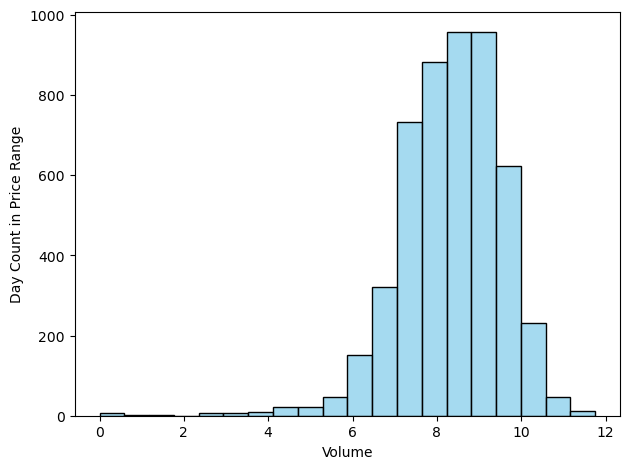

In [20]:
# Distribution of ['Volume']
sn.histplot(np.log1p(btc_data_daily['Volume']), bins=20, color='skyblue')
plt.ylabel('Day Count in Price Range')
plt.tight_layout()
plt.show()

The volume is at its lowest at the beginning of BTC which is absolutely normal. After that there is a huge increase. The distribution is a little bit left-skewed. Without this left tail the distribution would have been similar to the Gaussian distribution.

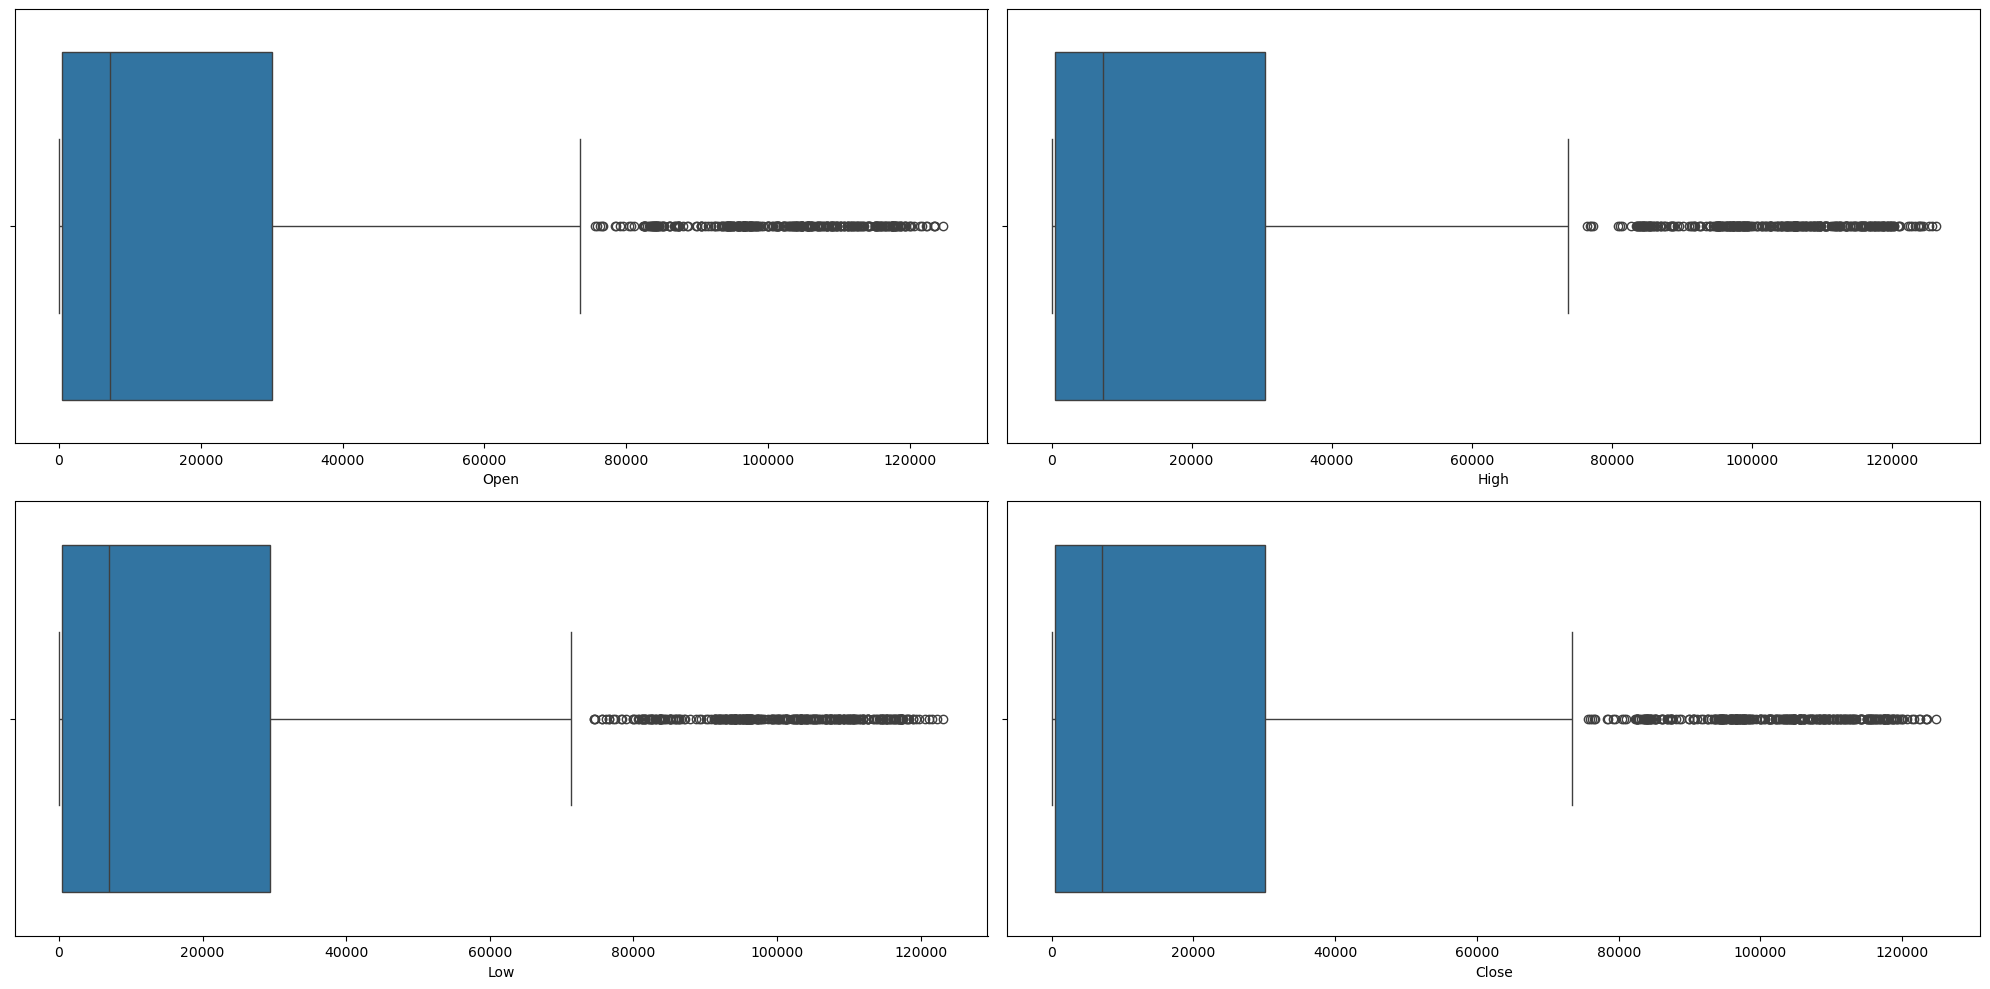

In [21]:
# Visualize box plots to see the outliers
plt.subplots(2, 2, figsize = (20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sn.boxplot(btc_data_daily[col], orient = 'h')
plt.tight_layout()
plt.show()

The boxplots above show the presence of a great amount of outliers which is because of the big jump in BTC price.

<Axes: >

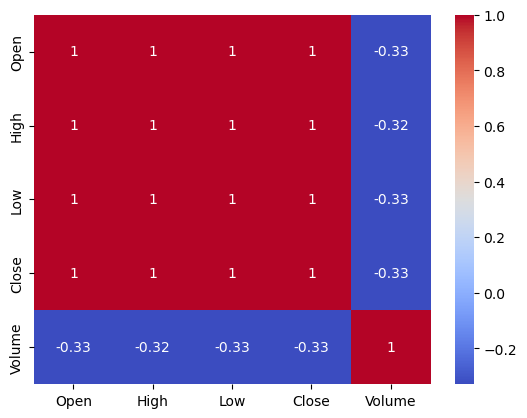

In [22]:
corr = btc_data_daily[['Open','High','Low','Close','Volume']].corr()
sn.heatmap(corr, annot = True, cmap = 'coolwarm')

All OHLC features have certain correlation. However, volume and the other features show weak negative correlation but does not mean that the volume decreases when the other features go up. Actually, volume is actually almost independent. However, let's perform a quick Pearson test to see the p-value and if those conclusions are right. The two parameters will be "Volume" and one of the OHLC features (as they are highly correlated, there is no meaning which one will be used); let's take "Close".

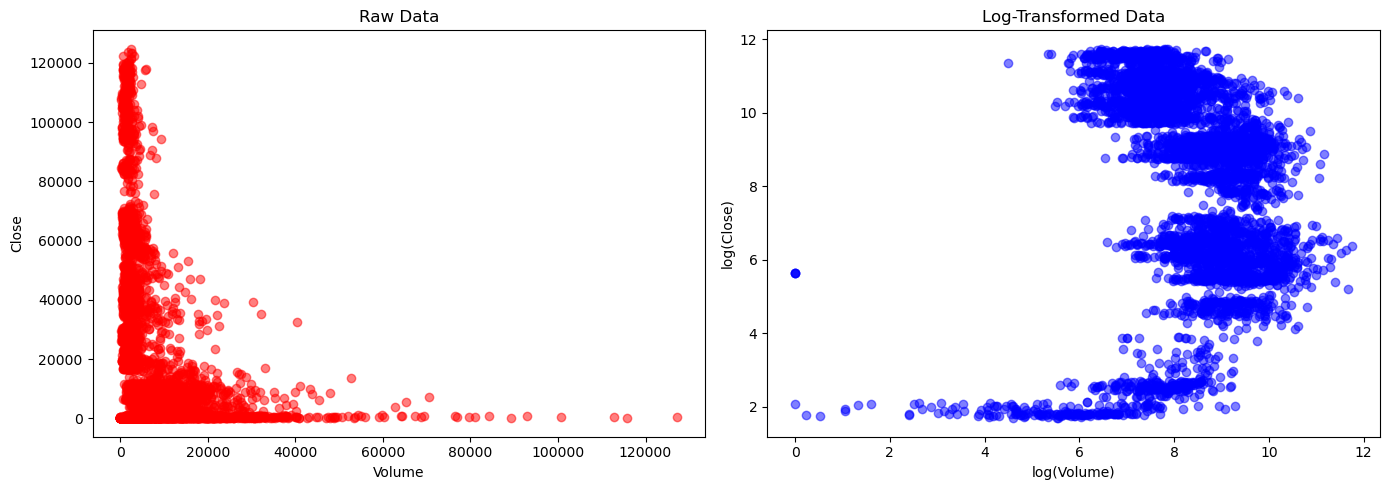

In [23]:
x_raw = btc_data_daily['Volume']
y_raw = btc_data_daily['Close']

plt.figure(figsize=(14, 5))

# Raw data
plt.subplot(1, 2, 1)
plt.scatter(x_raw, y_raw, color='red', alpha=0.5)
plt.title('Raw Data')
plt.xlabel('Volume')
plt.ylabel('Close')

# Log-transformed
x_log = np.log1p(x_raw)
y_log = np.log1p(y_raw)

plt.subplot(1, 2, 2)
plt.scatter(x_log, y_log, color='blue', alpha=0.5)
plt.title('Log-Transformed Data')
plt.xlabel('log(Volume)')
plt.ylabel('log(Close)')

plt.tight_layout()
plt.show()

The scatter plots show that both features do not have linear relationship. After log transformation, the relationship appears more structured and monotonic, meaning that changes in volume and price may have a nonlinear dependency. Most observations are concentrated near the lower left end in the first scatter plot.

In [24]:
# import scipy.stats as stats
corr, pval = stats.pearsonr(btc_data_daily['Close'], btc_data_daily['Volume'])
print(corr, pval)

-0.32611512930143266 3.97729465135637e-125


The p-value is a really small number ≈ 3.98 * 10^(-125), which is smaller than the border of 0.05. This means that the negative correlation with the other features is not random but is statistically significant. Nevertheless, the magnitude (≈ -0.33) means that the relationship is weak so no predictions can be performed. BUT from the histogram above it can be seen that the features are not normally distributed so Pearson's R test might not be appropriate here. Moreover, data has a lot of outliers. 
Some more methods will be tried:
- Spearman's R - for non-normal, non-linear data with outliers
- Kendall's Tau - better for small datasets
- Mutual Information - capturing nonlinear and non-monotonic relationships — e.g., when Volume spikes both during price rises and drops

In [25]:
# from scipy.stats import spearmanr
rho, pval = spearmanr(btc_data_daily['Close'], btc_data_daily['Volume'])
print(rho, pval)

-0.35463013026822987 3.569461900341037e-149


In [26]:
# from scipy.stats import kendalltau
tau, pval = kendalltau(btc_data_daily['Close'], btc_data_daily['Volume'])
print(tau, pval)

-0.25095437532288095 3.95799210597245e-157


In [27]:
# from sklearn.feature_selection import mutual_info_regression
X = btc_data_daily[['Volume']].values
y = btc_data_daily['Close'].values
mi = mutual_info_regression(X, y)
print(mi)

[0.43607862]


All other methods mentioned and performed above approve the result from the Pearson's test.

While Volume and Close are not linearly correlated, there may be a nonlinear or regime-dependent relationship (e.g., volume spikes during both strong rallies and crashes).

Therefore, Volume might not be a good direct predictor of price.

The features Volume and Close show a statistically significant but weak negative correlation. Their relationship is nonlinear and non-Gaussian, meaning traditional linear correlation (Pearson) underrepresents their dependency. Log-transformed or rank-based methods (e.g., Spearman, mutual information) better capture their behavior.

## Feature Engineering


In [28]:
def count_null_values(features):   
    print("Count of null values:")
    print()
    for col in features:
        print(f"{col}: {btc_daily_expanded[col].isna().sum()}")
        print('------------------')

In [29]:
def round_feature(features):
    for col in features:
        btc_daily_expanded[col].round(2)

- **Relative Strength Index (RSI)** |
  **Type:** Oscillator (a line chart) |
  **Sub-type:** Leading indicator |
  **Concerned with:** Momentum

**Formula**: 
<br>
    $\mathrm{RSI} = 100 - \dfrac{100}{1 + \mathrm{RS}}$
<br>
Where: RS (Relative Strength) = Average Gain / Average Loss
***

- **Moving Average Convergence Divergence (MACD)** |
  **Type:** Oscillator |
  **Sub-type:** Lagging indicator |
  **Concerned with:** Momentum

  
**Formula:**
- $\mathrm{MACD} = \mathrm{EMA}_{12} - \mathrm{EMA}_{26}$ (MACD_12_26_9 in the dataset features)
- $\mathrm{Signal} = \mathrm{EMA}_{9}(\mathrm{MACD})$ (MACDs_12_26_9 in the dataset features)
- $\mathrm{Histogram} = \mathrm{MACD} - \mathrm{Signal}$ (MACDh_12_26_9 in the dataset features)

12 → the fast EMA period (short-term moving average) - 12 days in this case <br>
26 → the slow EMA period (long-term moving average) - 26 days in this case <br>
9 → the signal line EMA period - 9 days in this case

EMA Formula just for reference:
$\mathrm{EMA}_t = \alpha \cdot P_t + (1 - \alpha) \cdot \mathrm{EMA}_{t-1}$

$\alpha = \frac{2}{N+1}$

**WHERE:** <br>
- Pt = Price at time t (usually Close) <br>
- N = Lookback period (e.g., 12, 26) <br>
- α = Smoothing factor
***

- **Bollinger Bands** |
  **Type:** Overlay |
  **Sub-type:** Lagging indicator |
  **Concerned with:** Volatility

  **Formula:**

  $ \text{Middle Band} = \text{SMA}_N $ <br>
  $ \text{Upper Band} = \text{SMA}_N + K \cdot \sigma_N $ <br>
  $ \text{Lower Band} = \text{SMA}_N - K \cdot \sigma_N $ <br>


  **WHERE:** <br>
  SMA_N = N-period Simple Moving Average <br>
  σ_N = N-period standard deviation of the price <br>
  K = number of standard deviations (usually 2)

  For reference: <br>
  $\text{SMA}_N = \frac{1}{N} \sum_{i=0}^{N-1} P_{t-i}$

  Pt-i = Price at time t−i (usually Close) <br>
  N = Lookback period


    - BBL_20_2.0_2.0 – Lower Band: SMA minus 2 standard deviations (SMA_N - Kσ_N)
    - BBM_20_2.0_2.0 – Middle Band: Simple Moving Average (SMA_N)
    - BBU_20_2.0_2.0 – Upper Band: SMA plus 2 standard deviations (SMA_N + Kσ_N)
    - BBB_20_2.0_2.0 – Bandwidth: measures width of the bands ((Upper - Lower)/Middle)
    - BBP_20_2.0_2.0 – Percent B: position of price relative to bands ((Price - Lower)/(Upper - Lower))
***

- **Moving Averages (MAs)** |
  **Type:** Overlay |
  **Sub-type:** Lagging indicator |
  **Concerned with:** Trend

  **SMA Formula:**
  $\text{SMA}_N = \frac{1}{N} \sum_{i=0}^{N-1} P_{t-i}$

  **WHERE:**
  - Pt-i = Price at time t−i (usually Close) <br>
  - N = Lookback period

  <br> </br>
  **EMA Formula:**
  $\mathrm{EMA}_t = \alpha \cdot P_t + (1 - \alpha) \cdot \mathrm{EMA}_{t-1}$

  $\alpha = \frac{2}{N+1}$

  **WHERE:** <br>
  - Pt = Price at time t (usually Close) <br>
  - N = Lookback period (e.g., 12, 26) <br>
  - α = Smoothing factor

- **Accelerator Oscillator** |
  **Type:** Oscillator |
  **Sub-type:** Leading indicator |
  **Concerned with:** Momentum

  $AC_t = AO_t - SMA_5(AO_t)$

    $AO_t = SMA_5\Big(\frac{High_t + Low_t}{2}\Big) - SMA_{34}\Big(\frac{High_t + Low_t}{2}\Big)$
    
    $AC_t = \Big[SMA_5\Big(\frac{High_t + Low_t}{2}\Big) - SMA_{34}\Big(\frac{High_t + Low_t}{2}\Big)\Big] - SMA_5\Big(SMA_5\Big(\frac{High_t + Low_t}{2}\Big) - SMA_{34}\Big(\frac{High_t + Low_t}{2}\Big)\Big)$


- **Stochastic** |
  **Type:** Oscillator |
  **Sub-type:** Leading indicator |
  **Concerned with:** Momentum

  $K_t = \frac{C_t - L_n}{H_n - L_n} \times 100$

    $D_t = SMA_m(K_t)$

  **WHERE**
  - Ct = Close price at time t
  - Ln = Lowest low over the past n periods
  - Hn = Highest high over the past n periods
  - SMA_m = Simple moving average over m periods (usually 3)

In [30]:
btc_daily_expanded = btc_data_daily

In [31]:
def generate_features():
    # RSI for 14 periods (days)
    btc_daily_expanded['RSI_14'] = ta.rsi(btc_daily_expanded['Close'], length = 14)

    # MACD 
    btc_daily_expanded.ta.macd(close = 'Close', fast = 12, slow = 26, signal = 9, append = True)

    # Bollinger Bands
    btc_daily_expanded.ta.bbands(close = 'Close', length = 20, std = 2, append = True)
    
    # df.ta.sma(length=20, append=True)  # 20-day SMA
    # This SMA is not needed because we have it already in the Bollinger Bands features
    btc_daily_expanded.ta.sma(length = 50, append = True)  # 50-day SMA
    btc_daily_expanded.ta.sma(length = 200, append = True) # 200-day SMA (long-term trend)
    
    # Exponential Moving Averages
    btc_daily_expanded.ta.ema(length = 12, append = True)
    btc_daily_expanded.ta.ema(length = 26, append = True)

    # Accelarator Oscillator
    btc_daily_expanded.ta.ao(high = 'High', low = 'Low', append = True)

    # Stochastic
    btc_daily_expanded.ta.stoch(high = 'High', low = 'Low', k = 14, d = 3, append = True)

In [32]:
generate_features()

In [33]:
new_features = ['RSI_14', 'MACD_12_26_9',
       'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0',
       'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'SMA_50',
       'SMA_200', 'EMA_12', 'EMA_26', 'AO_5_34', 'STOCHk_14_3_3',
       'STOCHd_14_3_3', 'STOCHh_14_3_3']

count_null_values(new_features)

Count of null values:

RSI_14: 1
------------------
MACD_12_26_9: 25
------------------
MACDh_12_26_9: 33
------------------
MACDs_12_26_9: 33
------------------
BBL_20_2.0_2.0: 19
------------------
BBM_20_2.0_2.0: 19
------------------
BBU_20_2.0_2.0: 19
------------------
BBB_20_2.0_2.0: 19
------------------
BBP_20_2.0_2.0: 19
------------------
SMA_50: 49
------------------
SMA_200: 199
------------------
EMA_12: 11
------------------
EMA_26: 25
------------------
AO_5_34: 33
------------------
STOCHk_14_3_3: 15
------------------
STOCHd_14_3_3: 17
------------------
STOCHh_14_3_3: 17
------------------


It is normal that there are NaN values in the first days. This happens because there is not enough data for the calculations.
The null values can be replaced with 0 because there are no data. However, since it is not appropriate for some ML algorithms, I will leave the NaN values or will remove the them if the model is not capable of threating NaN values.
Replacing with 0 may give false signals to the model.
However, I will round them to 2 digits after the decimal comma.

In [34]:
round_feature(new_features)

In [35]:
btc_daily_expanded.sample(10)

,Open,High,Low,Close,Volume,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0_2.0,...,BBB_20_2.0_2.0,BBP_20_2.0_2.0,SMA_50,SMA_200,EMA_12,EMA_26,AO_5_34,STOCHk_14_3_3,STOCHd_14_3_3,STOCHh_14_3_3
Timestamp,,,,,,,,,,,,,,,,,,,,,
2016-08-18,570.48,575.87,568.79,571.67,3898.527051,37.864560,-17.082675,0.502599,-17.585274,539.208696,...,15.903755,0.348437,631.1878,509.47755,580.375384,597.458059,-46.132235,51.134945,60.657763,-9.522818
2019-06-02,8538.54,8833.97,8523.68,8680.63,4671.477801,68.120218,592.639520,-41.255184,633.894703,7178.940597,...,23.678496,0.778827,6634.5600,4603.48075,8370.400814,7777.761294,1362.365118,70.645950,75.092440,-4.446490
2020-07-07,9294.00,9385.81,9217.66,9239.28,4811.381959,49.747456,-57.420830,3.627803,-61.048633,8886.953270,...,7.520665,0.507330,9355.2614,8411.86665,9188.510773,9245.931603,-220.631294,39.055216,32.669118,6.386098
2012-01-24,6.52,6.57,6.00,6.55,85.446241,57.149473,NaN,NaN,NaN,6.120847,...,18.601263,0.341871,NaN,NaN,6.656340,NaN,NaN,59.856631,67.204301,-7.347670
2018-12-06,3729.38,3844.79,3548.76,3595.43,14552.529855,27.592517,-510.967283,15.140633,-526.107916,3141.410089,...,51.943770,0.205975,5469.7654,6480.23005,4022.363343,4533.330626,-1176.186471,24.196405,27.261057,-3.064653
2021-12-12,48713.47,50800.00,48397.64,50530.23,1220.838102,41.096078,-2819.392383,-285.194968,-2534.197415,45257.285619,...,30.290376,0.326390,58490.1684,46710.59935,51036.810064,53856.202447,-7762.704088,40.797782,38.370886,2.426896
2021-07-25,33850.00,34854.88,33679.12,34379.00,1690.638031,55.332197,-469.787905,371.995960,-841.783865,30110.532654,...,15.388236,0.850343,34186.9232,44622.52720,32620.785570,33090.573474,-378.321971,77.340666,65.203633,12.137033
2016-03-23,416.00,419.00,413.44,418.67,4856.996436,53.953828,-0.024709,-0.035596,0.010887,401.434149,...,5.377528,0.776960,409.2870,358.24240,413.708413,413.733122,-7.491941,64.656256,53.003297,11.652959
2024-10-05,62080.00,62368.00,61699.00,62063.00,449.654242,50.752109,495.511334,-399.359109,894.870442,58756.850300,...,12.900107,0.408051,60620.0600,63524.63500,62417.848415,61922.337081,1046.255882,26.619535,20.250620,6.368915


A quick check for correlated columns will be done to see if there are some unnecessary features.

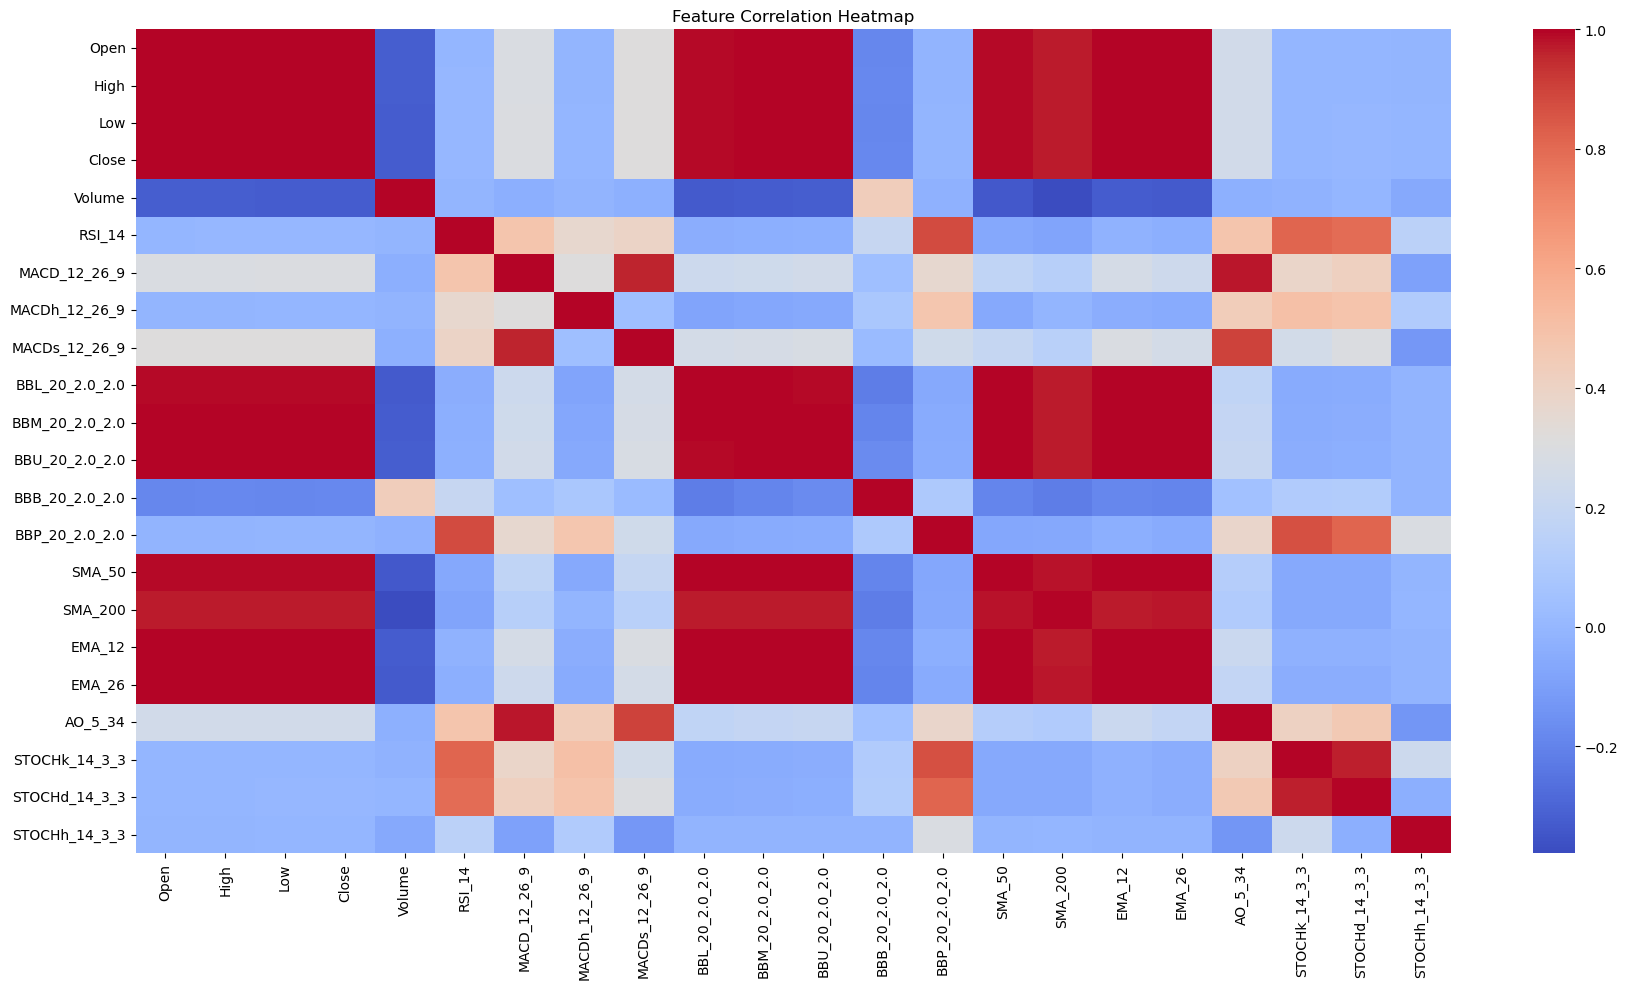

In [36]:
corr_matrix = btc_daily_expanded.corr()

plt.figure(figsize=(18, 10))
sn.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

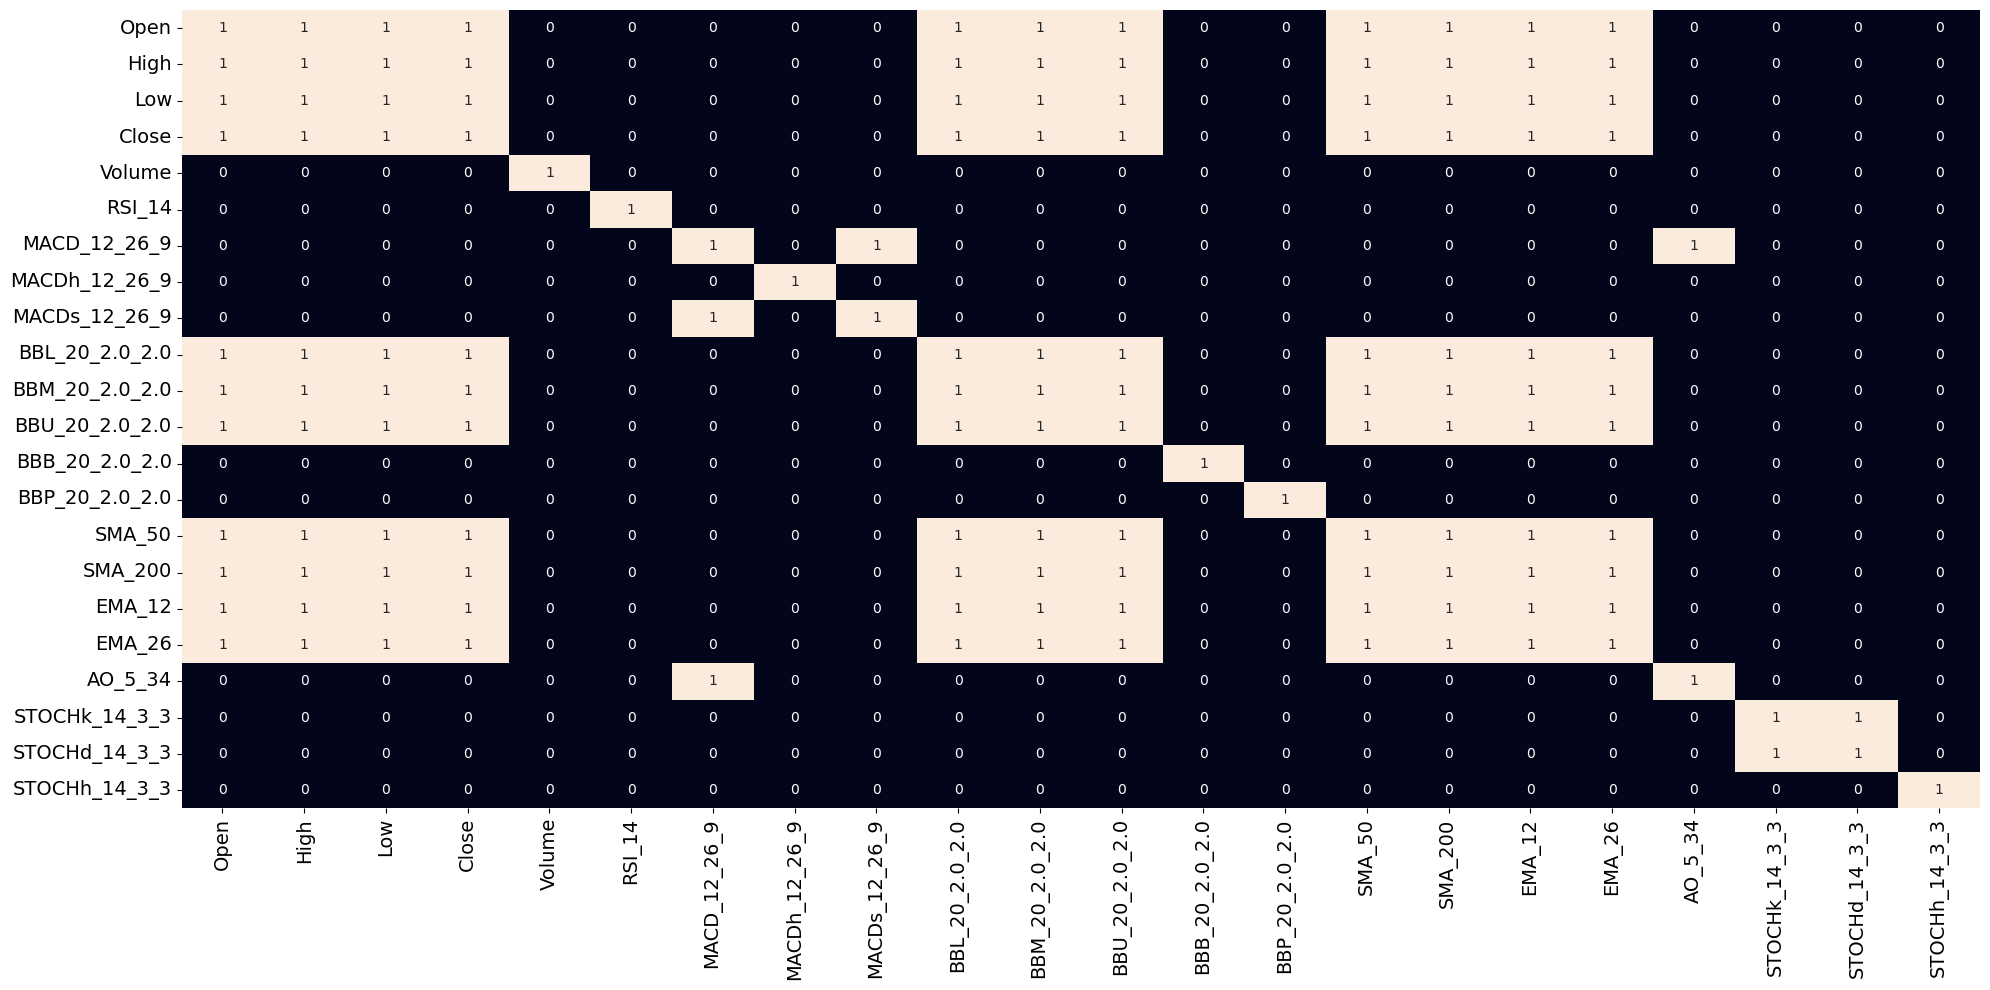

In [37]:
plt.figure(figsize=(20, 10))

sn.heatmap(btc_daily_expanded.corr() > 0.9, annot=True, cbar=False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

As it can be seen from the heatmaps above, there are some features which are highly correlated. Let's consider their removal.
- OHLC are highly correlated with each another so it is enough to leave only one - for example 'Close'.
- From the Bollinger Bands I will remove some, too - such as BBL, BBM and BBU. They have high correlation with the OHLC features and also with the SMA because they contain it.
- I will also remove the SMA because they have strong correlation with the OHLC features as well as the Bollinger Bands features. 

In [38]:
btc_daily_expanded.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'RSI_14', 'MACD_12_26_9',
       'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0',
       'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'SMA_50',
       'SMA_200', 'EMA_12', 'EMA_26', 'AO_5_34', 'STOCHk_14_3_3',
       'STOCHd_14_3_3', 'STOCHh_14_3_3'],
      dtype='object')

In [39]:
drop_cols = [
    'Open', 'High', 'Low',
    'BBL_20_2.0_2.0',
    'BBM_20_2.0_2.0',
    'BBU_20_2.0_2.0',
    'SMA_50', 'SMA_200',
    'STOCHh_14_3_3',
]

btc_daily_expanded = btc_daily_expanded.drop(columns = drop_cols)

In [40]:
btc_daily_expanded.columns

Index(['Close', 'Volume', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'EMA_12', 'EMA_26',
       'AO_5_34', 'STOCHk_14_3_3', 'STOCHd_14_3_3'],
      dtype='object')

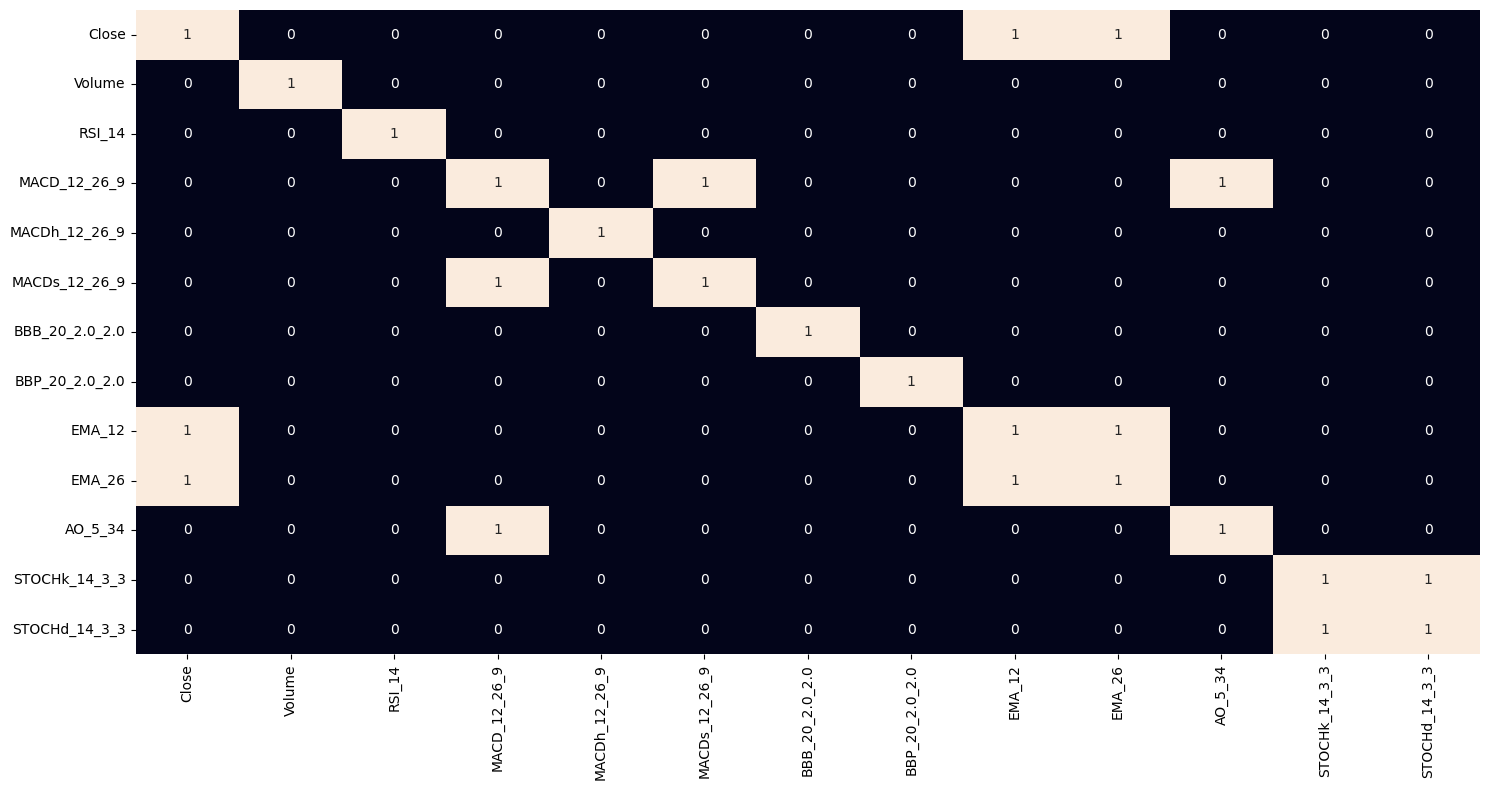

In [41]:
plt.figure(figsize = (15, 8))

sn.heatmap(btc_daily_expanded.corr() > 0.9, annot = True, cbar = False)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.tight_layout()
plt.show()

Now the correlation heatmap looks much better. There are some other correlated features such as EMA which has a similar direction with Close but EMA is a great indicator.

In [42]:
high_corr_cols = btc_daily_expanded[(btc_daily_expanded.corr() > 0.9)]

In [43]:
high_corr_cols.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5037 entries, 2012-01-01 to 2025-10-15
Freq: D
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Close           0 non-null      float64
 1   Volume          0 non-null      float64
 2   RSI_14          0 non-null      float64
 3   MACD_12_26_9    0 non-null      float64
 4   MACDh_12_26_9   0 non-null      float64
 5   MACDs_12_26_9   0 non-null      float64
 6   BBB_20_2.0_2.0  0 non-null      float64
 7   BBP_20_2.0_2.0  0 non-null      float64
 8   EMA_12          0 non-null      float64
 9   EMA_26          0 non-null      float64
 10  AO_5_34         0 non-null      float64
 11  STOCHk_14_3_3   0 non-null      float64
 12  STOCHd_14_3_3   0 non-null      float64
dtypes: float64(13)
memory usage: 680.0 KB


In [44]:
# I will use these features to see if the models performance will get better
btc_daily_expanded_new = btc_daily_expanded.copy()
def add_new_features():
    
    # --- 1. Lagged returns ---
    btc_daily_expanded_new['Return_1'] = btc_daily_expanded_new['Close'].pct_change(1)
    btc_daily_expanded_new['Return_2'] = btc_daily_expanded_new['Close'].pct_change(2)
    btc_daily_expanded_new['Return_3'] = btc_daily_expanded_new['Close'].pct_change(3)
    
    # --- 2. Rolling volatility ---
    btc_daily_expanded_new['Vol_5']  = btc_daily_expanded_new['Return_1'].rolling(5).std()
    btc_daily_expanded_new['Vol_10'] = btc_daily_expanded_new['Return_1'].rolling(10).std()
    btc_daily_expanded_new['Vol_20'] = btc_daily_expanded_new['Return_1'].rolling(20).std()
    
    # --- 3. Momentum / trend features ---
    btc_daily_expanded_new['Close_EMA_diff'] = btc_daily_expanded_new['EMA_12'] - btc_daily_expanded_new['EMA_26']
    btc_daily_expanded_new['BB_width'] = btc_daily_expanded_new['BBB_20_2.0_2.0'] 
    btc_daily_expanded_new['AO_smooth'] = btc_daily_expanded_new['AO_5_34'].rolling(3).mean()
    
    # --- 4. Z-score normalized indicators ---
    for col in ['RSI_14', 'MACD_12_26_9', 'AO_5_34']:
        btc_daily_expanded_new[col + '_z'] = (
            btc_daily_expanded_new[col] - btc_daily_expanded_new[col].rolling(20).mean()) / btc_daily_expanded_new[col].rolling(20).std()
    
    # --- 5. Regime detection ---
    btc_daily_expanded_new['Bull'] = (
        btc_daily_expanded_new['EMA_12'].rolling(20).mean() > btc_daily_expanded_new['EMA_26'].rolling(50).mean()).astype(int)
    btc_daily_expanded_new['Bear'] = (
        btc_daily_expanded_new['EMA_12'].rolling(20).mean() < btc_daily_expanded_new['EMA_26'].rolling(50).mean()).astype(int)
    
    # --- 6. Volume features ---
    btc_daily_expanded_new['Volume_z'] = (
        btc_daily_expanded_new['Volume'] - btc_daily_expanded_new['Volume'].rolling(20).mean()) / btc_daily_expanded_new['Volume'].rolling(20).std()
    btc_daily_expanded_new['Volume_Change'] = btc_daily_expanded_new['Volume'].pct_change(1)
    
    
    # Replacing Inf with NaN
    btc_daily_expanded_new.replace([np.inf, -np.inf], np.nan, inplace = True)
    
    # Dropping any remaining NaNs
    btc_daily_expanded_new.dropna(inplace = True)

In [45]:
print(btc_daily_expanded.shape)
print(btc_daily_expanded_new.shape)

(5037, 13)
(5037, 13)


## Model Training

#### Data splitting

In [46]:
# df['Target'] = df['Close'].shift(-1) - previous version 
# But it is better for models to get the return; otherwise, data leakage is available

btc_daily_expanded["Target"] = np.log(btc_daily_expanded["Close"].shift(-1) / btc_daily_expanded["Close"])
btc_daily_expanded = btc_daily_expanded.dropna()

$ \text{log\_return} = \ln\left( \frac{P_{t+1}}{P_t} \right) $
$ P_t $ = today price  
$ P_{t+1} $ = price tomorrow


In [47]:
# 70% for testing; 15% for validation; 15% for testing
n = len(btc_daily_expanded)
train_size = int(n * 0.7)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

train = btc_daily_expanded.iloc[:train_size]
val = btc_daily_expanded.iloc[train_size : train_size + val_size]
test = btc_daily_expanded.iloc[train_size + val_size:]

In [48]:
features = btc_daily_expanded.drop(columns = 'Target').columns.tolist()

In [49]:
features

['Close',
 'Volume',
 'RSI_14',
 'MACD_12_26_9',
 'MACDh_12_26_9',
 'MACDs_12_26_9',
 'BBB_20_2.0_2.0',
 'BBP_20_2.0_2.0',
 'EMA_12',
 'EMA_26',
 'AO_5_34',
 'STOCHk_14_3_3',
 'STOCHd_14_3_3']

In [50]:
attributes = btc_daily_expanded[features]

In [51]:
target = btc_daily_expanded.Target

In [52]:
x_train = attributes.iloc[:train_size]
y_train = target.iloc[:train_size]

In [53]:
print(x_train.shape)
print(y_train.shape)

(3502, 13)
(3502,)


In [54]:
x_val = attributes.iloc[train_size:train_size + val_size]
y_val = target.iloc[train_size:train_size + val_size]

In [55]:
print(x_val.shape)
print(y_val.shape)

(750, 13)
(750,)


In [56]:
x_test = attributes.iloc[train_size + val_size:]
y_test = target.iloc[train_size + val_size:]

In [57]:
print(x_test.shape)
print(y_test.shape)

(751, 13)
(751,)


#### Scaling

In [58]:
scaler = StandardScaler()

In [59]:
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

Fit_transform is performed only on the training data separately in order to prevent data leakage.

### MODELS

### XGBoost

**Let's observe the performance of XGBoost.** 
<br>
XGBoost which is a scalable, distributed gradient-boosted decision tree (GBDT) library that uses an ensemble learning method by combining multiple weak models (decision trees) sequentially to form a stronger model.

In [60]:
# This function will be used to facilitate the process of prediciting and evaluation of the accuracy
def prediction_accuracy(Model):
    preds = Model.predict(x_test_scaled)
    actual_up = y_test > 0
    pred_up   = preds > 0
    direction_accuracy = (actual_up == pred_up).mean()

    print("Direction accuracy:", direction_accuracy)


First, I will train the model without passing any parameters to see how bad it performs.

In [61]:
no_parameter_model = XGBRegressor() 

# The default parameters are n_estimators=100, max_depth=3, learning_rate=0.1

no_parameter_model.fit(x_train_scaled, y_train,
          eval_set=[(x_val_scaled, y_val)],
          verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [62]:
y_pred_train = no_parameter_model.predict(x_train_scaled)
train_r2 = r2_score(y_train, y_pred_train)
print("Train R2:", train_r2)

y_pred_val = no_parameter_model.predict(x_val_scaled)
train_r2 = r2_score(y_val, y_pred_val)
print("Validation R2:", train_r2)

prediction_accuracy(no_parameter_model)

Train R2: 0.9242252444750443
Validation R2: -0.6832861786600932
Direction accuracy: 0.5086551264980027


The train R2 shows that the model is too good for financial data which means that it overfits but it is normal because it is not properly tuned.
The validation R2 is terrible. 
The model does not perform well on the validation set. It is even worse than a model which always predicts the mean.
The accuracy of the untuned XGBoost on the test set is decent having in mind the fact that financial time series are very noisy and often close to a random walk. The model is not learning meaningful patterns and it is basically random. That is why, improvement will require careful hyperparameter tuning. 

Default n_estimators=100 is a too small number whereas learning_rate=0.1 is too high for financial data.

In [63]:
# Accuracy with random hyperparameters; good practice is: more estimators, low learning rate
model2 = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.8
)

model2.fit(x_train_scaled, y_train,
          eval_set=[(x_val_scaled, y_val)],
          verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [64]:
y_pred_train = model2.predict(x_train_scaled)
train_r2 = r2_score(y_train, y_pred_train)
print("Train R2:", train_r2)


y_pred_val = model2.predict(x_val_scaled)
train_r2 = r2_score(y_val, y_pred_val)
print("Validation R2:", train_r2)

prediction_accuracy(model2)

Train R2: 0.7091493329945642
Validation R2: -0.22139438227804553
Direction accuracy: 0.5059920106524634


The random-tuned XGBRegressor gave a worse result on the train and test data meaning lower overfitting over the train data. It performs better on the validation set than the previous model but it is still bad.

Now Optuna will be used to find the best hyperparameters so that the model can achieve higher accuracy. 

In [65]:
def objective(trial):
    # values in the pointed intervals are being tested
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 0.5),
        "subsample": trial.suggest_float("subsample", 0.5, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 2),
        "objective": "reg:squarederror",
    }

    val_model = XGBRegressor(**params)
    val_model.fit(
        x_train_scaled, y_train,
        eval_set=[(x_val_scaled, y_val)],
        verbose=False
    )


    preds = val_model.predict(x_val_scaled)
    score = ((preds > 0) == (y_val > 0)).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2025-11-23 10:30:18,160] A new study created in memory with name: no-name-46948699-b361-42f4-b342-ed574d3bc33d
[I 2025-11-23 10:30:19,010] Trial 0 finished with value: 0.49466666666666664 and parameters: {'n_estimators': 642, 'learning_rate': 0.017246484282728305, 'max_depth': 3, 'min_child_weight': 1, 'gamma': 0.37152630207902687, 'subsample': 0.5362473348574682, 'colsample_bytree': 0.8446854575355933, 'reg_alpha': 0.9755585365994208, 'reg_lambda': 0.8186722611691761}. Best is trial 0 with value: 0.49466666666666664.
[I 2025-11-23 10:30:20,096] Trial 1 finished with value: 0.49466666666666664 and parameters: {'n_estimators': 861, 'learning_rate': 0.005864528855718508, 'max_depth': 5, 'min_child_weight': 8, 'gamma': 0.27078586609663907, 'subsample': 0.8740550404949616, 'colsample_bytree': 0.3428951250929914, 'reg_alpha': 0.7024992562112035, 'reg_lambda': 0.14697521309684933}. Best is trial 0 with value: 0.49466666666666664.
[I 2025-11-23 10:30:21,082] Trial 2 finished with value: 0.

Best params: {'n_estimators': 642, 'learning_rate': 0.017246484282728305, 'max_depth': 3, 'min_child_weight': 1, 'gamma': 0.37152630207902687, 'subsample': 0.5362473348574682, 'colsample_bytree': 0.8446854575355933, 'reg_alpha': 0.9755585365994208, 'reg_lambda': 0.8186722611691761}
Best accuracy: 0.49466666666666664


In [66]:
optimized_model = XGBRegressor(**study.best_params, objective="reg:squarederror")
optimized_model.fit(x_train_scaled, y_train)

prediction_accuracy(optimized_model)


Direction accuracy: 0.5299600532623169


With the new hyperparameters the model gives accuracy of 0.49466... on the validation data and 0.5299 on the test data, which is better than the previous models especially if the validation set is being considered. The result shows that the model is actually capturing weak, real predictive patterns in BTC log returns. That’s a subtle but important distinction in noisy financial data.

Now I will try improving the model performance by providing a slightly different approach. I will use walk-forward tuning.
I will split the data again for better understanding and clean working process.

In [67]:
# Spliting and scaling the data

X_all = btc_daily_expanded[features]
y_all = btc_daily_expanded['Target']

split_idx = int(len(X_all) * 0.8)
X_train_wf, X_test_wf = X_all[:split_idx], X_all[split_idx:]
Y_train_wf, Y_test_wf = y_all[:split_idx], y_all[split_idx:]

scaler = StandardScaler()
scaler.fit(X_train_wf)
X_train_scaled_wf = scaler.transform(X_train_wf)
X_test_scaled_wf = scaler.transform(X_test_wf)

In [68]:
def walk_forward_xgboost(X, y, n_splits=4, val_size=0.15, n_trials = 60):

    # 1. Build walk-forward splits
    def build_walk_forward_splits(X, y, n_splits=4, val_size = 0.15):
        splits = []
        n = len(X)
        fold_len = int(n * (1 - val_size))
        for i in range(n_splits):
            train_end = fold_len + int((i / n_splits) * (n - fold_len))
            train_idx = np.arange(0, train_end)
            val_idx   = np.arange(train_end, min(train_end + int(val_size * n), n))
            if len(val_idx) > 0:
                splits.append((train_idx, val_idx))
        return splits

    # 2. Walk-forward scoring function
    def walk_forward_score(model, X, y, splits):
        scores = []
        for train_idx, val_idx in splits:
            X_train, Y_train = X[train_idx], y[train_idx]
            X_val,   Y_val   = X[val_idx], y[val_idx]

            model.fit(X_train, Y_train)
            preds = model.predict(X_val)
            score = ((preds > 0) == (Y_val > 0)).mean()
            scores.append(score)
        return np.mean(scores)

    # 3. Optuna objective
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 0, 0.5),
            "subsample": trial.suggest_float("subsample", 0.5, 0.9),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.9),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 2),
            "objective": "reg:squarederror",
            "tree_method": "hist",
        }

        model = XGBRegressor(**params)
        score = walk_forward_score(model, X, y, splits)
        return score

    # 4. Run Optuna
    splits = build_walk_forward_splits(X, y, n_splits = n_splits, val_size = val_size)
    study = optuna.create_study(direction = "maximize")
    study.optimize(objective, n_trials=n_trials)

    print("Best parameters:", study.best_params)
    print("Best walk-forward accuracy:", study.best_value)

    # 5. Train final model on full training set
    best_model = XGBRegressor(**study.best_params)
    best_model.fit(X, y)
    return best_model

In [69]:
# A function to see the results similar to the one above but this one has a different signature
def prediction_accuracy(Model, X_test, y_test):
    preds = Model.predict(X_test)
    actual_up = y_test > 0
    pred_up = preds > 0
    direction_accuracy = (actual_up == pred_up).mean()
    print("Direction accuracy:", direction_accuracy)
    return direction_accuracy

In [70]:
#walk_forward_splitting(btc_daily_expanded)
best_model_wf = walk_forward_xgboost(X_train_scaled_wf, Y_train_wf, n_splits = 4, val_size = 0.15, n_trials = 60)

[I 2025-11-23 10:31:01,741] A new study created in memory with name: no-name-f17a091f-baff-4699-a6f0-0373bb311e40
C:\Users\aneli\AppData\Local\Temp\ipykernel_8216\1320149085.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_train, Y_train = X[train_idx], y[train_idx]
C:\Users\aneli\AppData\Local\Temp\ipykernel_8216\1320149085.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_val,   Y_val   = X[val_idx], y[val_idx]
[I 2025-11-23 10:31:02,599] Trial 0 finished with value: 0.49942227808809736 and parameters: {'n_estimators': 514, 'learning_rate': 0.048029952798646476, 'max_depth': 3, 'min_child_weight': 8, 'ga

Best parameters: {'n_estimators': 514, 'learning_rate': 0.048029952798646476, 'max_depth': 3, 'min_child_weight': 8, 'gamma': 0.4158655554158213, 'subsample': 0.8108701164232289, 'colsample_bytree': 0.7670046762994226, 'reg_alpha': 0.7765866291515705, 'reg_lambda': 1.6944150859569036}
Best walk-forward accuracy: 0.49942227808809736


In [71]:
prediction_accuracy(best_model_wf, X_test_scaled_wf, Y_test_wf)
#preds = best_model_wf.predict(x_test_scaled)
#final_score = ((preds > 0) == (y_test > 0)).mean()
#print("Final Test Accuracy:", final_score)

Direction accuracy: 0.5214785214785215


np.float64(0.5214785214785215)

**Walk-forward accuracy vs final test accuracy after Optuna tuning**

**Walk-forward accuracy: 0.4994** <br>
This is the average accuracy across the multiple training/validation splits during Optuna tuning.
It’s so low because BTC daily returns are extremely noisy. Many splits will naturally have accuracy around 0.5 (random chance).
The walk-forward average is conservative by design — it prevents overfitting to any single split.
<br> </br>
**Final test accuracy: 0.5214**
<br>
This is the accuracy on the completely unseen test set, after training the model on all training data.
This is a realistic estimate of how the model would perform in live trading.
Getting above 0.52 is actually quite strong for daily BTC direction prediction.

This pattern — low walk-forward score but higher test accuracy — is normal in noisy financial time-series. 
It means that the model found some predictive signal but the in-sample splits are very unstable.

The best parameters found by the tuning tell that:

High n_estimators → the model is learning slowly, which is good for noisy data. <br>
Low learning rate → stable updates. <br>
Max depth 7 → relatively complex tree, allowing it to capture subtle patterns. <br>
Subsample/colsample ~0.7–0.8 → regularization to prevent overfitting. <br>
Alpha/lambda regularization → XGBoost is penalizing complexity, again preventing overfitting.

Having in mind this result, the conclusion is that the model is realistic and robust, not overfitting.
A ~0.53 test accuracy is already predictive in BTC daily returns — most models are stuck at ~0.50.

Now I will observe the same model but first, I will add some features to see if they will improve its performance. The data observations are not many so when rows are few, it is a good idea to have more features. Lagged returns, rolling volatility, price momentums, normalized indicators and regime detection features will be added.

In [72]:
btc_daily_expanded_new.columns

Index(['Close', 'Volume', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'EMA_12', 'EMA_26',
       'AO_5_34', 'STOCHk_14_3_3', 'STOCHd_14_3_3'],
      dtype='object')

In [73]:
add_new_features()

btc_daily_expanded_new['Target'] = np.log(
    btc_daily_expanded_new['Close'].shift(-1) / btc_daily_expanded_new['Close']
)
btc_daily_expanded_new = btc_daily_expanded_new.dropna()

features_new = ['Close', 'Volume', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9',
                'MACDs_12_26_9', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'EMA_12', 
                'EMA_26', 'AO_5_34', 'STOCHk_14_3_3', 'STOCHd_14_3_3', 
                'Return_1', 'Return_2', 'Return_3', 'Vol_5', 'Vol_10', 'Vol_20', 
                'Close_EMA_diff', 'BB_width', 'AO_smooth', 'RSI_14_z', 
                'MACD_12_26_9_z', 'AO_5_34_z', 'Bull', 'Bear', 'Volume_z', 'Volume_Change']

# Spliting and scaling the data
X_all_new = btc_daily_expanded_new[features_new].values
y_all_new = btc_daily_expanded_new['Target'].values

# Train-test split (80/20)
split_idx_new = int(len(X_all_new) * 0.8)
X_train_wf_new, X_test_wf_new = X_all_new[:split_idx_new], X_all_new[split_idx_new:]
Y_train_wf_new, Y_test_wf_new = y_all_new[:split_idx_new], y_all_new[split_idx_new:]

# Scaling
scaler = StandardScaler()
scaler.fit(X_train_wf_new)
X_train_scaled_wf_new = scaler.transform(X_train_wf_new)
X_test_scaled_wf_new = scaler.transform(X_test_wf_new)

best_model_wf_with_new_features = walk_forward_xgboost(X_train_scaled_wf_new, Y_train_wf_new, n_splits=4, val_size=0.15, n_trials=60)


[I 2025-11-23 10:32:33,570] A new study created in memory with name: no-name-479c5f66-72a2-40b0-b088-24b0bc02baa2
[I 2025-11-23 10:32:35,865] Trial 0 finished with value: 0.5040848770398036 and parameters: {'n_estimators': 579, 'learning_rate': 0.041690794552809066, 'max_depth': 5, 'min_child_weight': 4, 'gamma': 0.17553347002666347, 'subsample': 0.8411553751924158, 'colsample_bytree': 0.8340791355351229, 'reg_alpha': 0.11560029092063506, 'reg_lambda': 0.49246527435164344}. Best is trial 0 with value: 0.5040848770398036.
[I 2025-11-23 10:32:38,303] Trial 1 finished with value: 0.5040848770398036 and parameters: {'n_estimators': 778, 'learning_rate': 0.02896108314618849, 'max_depth': 5, 'min_child_weight': 5, 'gamma': 0.29317632541265565, 'subsample': 0.7663340887823447, 'colsample_bytree': 0.8866831762193752, 'reg_alpha': 0.2686331877625434, 'reg_lambda': 1.5707483345361022}. Best is trial 0 with value: 0.5040848770398036.
[I 2025-11-23 10:32:40,480] Trial 2 finished with value: 0.5040

Best parameters: {'n_estimators': 579, 'learning_rate': 0.041690794552809066, 'max_depth': 5, 'min_child_weight': 4, 'gamma': 0.17553347002666347, 'subsample': 0.8411553751924158, 'colsample_bytree': 0.8340791355351229, 'reg_alpha': 0.11560029092063506, 'reg_lambda': 0.49246527435164344}
Best walk-forward accuracy: 0.5040848770398036


In [74]:
print("Train Accuracy:")
prediction_accuracy(best_model_wf_with_new_features, X_train_scaled_wf_new, Y_train_wf_new)

print("Test Accuracy:")
prediction_accuracy(best_model_wf_with_new_features, X_test_scaled_wf_new, Y_test_wf_new)

Train Accuracy:
Direction accuracy: 0.5376506024096386
Test Accuracy:
Direction accuracy: 0.5200803212851406


np.float64(0.5200803212851406)

**Brief analysis of the hyperparameters:**

High n_estimators + low learning_rate → model learns slowly, which is good for noisy BTC data. <br>
Shallow trees (max_depth=3) → avoids overfitting, especially with many features. <br>
Subsample/colsample ~0.5–0.6 → prevents overfitting. <br>
Alpha/Lambda regularization → penalizes complexity to stabilize learning.

The new added features helped the model to accelarate its accuracy on the training set.

The model now generalizes well and does not overfit. Getting above 0.53 on the training set and ~0.51 on the test set is meaningful — in crypto daily prediction, even small edges are valuable. In crypto other external factors are influential, too. 

#### Conclusion: 
The results from the XGBoost show that the model is able to correctly predict the direction of BTC daily returns slightly better than random chance (0.5). While the edge is small, in financial time series, even 1–2% above 0.5 is considered meaningful due to the extreme noise in daily crypto returns.

Shallow trees (max_depth=3) and low learning rate → avoid overfitting. <br>
Subsampling and regularization → stabilize learning in noisy data. <br>
The model is robust, generalizes well, and avoids overfitting to any single period of BTC data.

This XGBoost model provides a small but statistically meaningful edge in predicting BTC daily return direction. The pipeline is robust, properly scaled, and uses walk-forward validation to prevent overfitting. While daily accuracy remains modest due to inherent market noise, the model’s predictive signals could be a useful component in a larger trading or portfolio strategy.

### Random Forest

In [75]:
print(len(x_train_scaled), len(y_train))
print(len(x_val_scaled), len(y_val))
print(len(x_test_scaled), len(y_test))

3502 3502
750 750
751 751


In [76]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train_scaled, y_train)

pred_train = rf.predict(x_train_scaled)
pred_val = rf.predict(x_val_scaled)
pred_test = rf.predict(x_test_scaled)


rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_val   = np.sqrt(mean_squared_error(y_val, pred_val))
rmse_test  = np.sqrt(mean_squared_error(y_test, pred_test))

print("RMSE Train:", rmse_train)
print("RMSE Val:", rmse_val)
print("RMSE Test:", rmse_test)

RMSE Train: 0.03783902717808306
RMSE Val: 0.030950905221590767
RMSE Test: 0.02587041249644257


The RMSE are quite good actually. They show that the model does not overfit but generalizes instead.
Random Forest has 4 key hyperparameters:
n_estimators,
max_depth,
min_samples_split,
min_samples_leaf.

Now I will try to fine-tune the model using the best parameters found by Optuna. I tried to do it with GrivSearch but it is a really heavy process while Optuna is slightly lighter.

In [77]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 6, 14),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(x_train_scaled, y_train)

    preds = model.predict(x_val_scaled)

    rmse = sqrt(mean_squared_error(y_val, preds))
    return rmse

study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=60, show_progress_bar=True)


[I 2025-11-23 10:34:53,488] A new study created in memory with name: no-name-1a2fada5-3eae-446a-b176-5cb7a9378daf


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2025-11-23 10:34:57,608] Trial 0 finished with value: 0.031521904845096455 and parameters: {'n_estimators': 791, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.031521904845096455.
[I 2025-11-23 10:34:58,882] Trial 1 finished with value: 0.031039461882938515 and parameters: {'n_estimators': 237, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 0.031039461882938515.
[I 2025-11-23 10:35:02,697] Trial 2 finished with value: 0.031348539107854775 and parameters: {'n_estimators': 595, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 0.031039461882938515.
[I 2025-11-23 10:35:05,710] Trial 3 finished with value: 0.031221376364963804 and parameters: {'n_estimators': 464, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 2

In [78]:
best_params = study.best_params

final_model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

x_trainval_scaled = scaler.fit_transform(pd.concat([x_train, x_val]))
y_trainval = pd.concat([y_train, y_val])

final_model.fit(x_trainval_scaled, y_trainval)

x_test_scaled = scaler.transform(x_test)
pred_test = final_model.predict(x_test_scaled)

rmse_test = sqrt(mean_squared_error(y_test, pred_test))
print("Test RMSE:", rmse_test)


Test RMSE: 0.026228140235292904


In [79]:
true_dir = (y_test > 0).astype(int)
pred_dir = (pred_test > 0).astype(int)
directional_acc = (true_dir == pred_dir).mean()
print("Test Directional Accuracy:", directional_acc)


Test Directional Accuracy: 0.49533954727030627


Conclusion: 
The model is not overfitting — the test error is even slightly lower than the train RMSE, indicating stable training.
Random Forest is able to predict the magnitude of the log-return fairly well (small RMSE values).
The model cannot predict the direction of price movement better than random (50%).


I will perform the same algorithm on the extended dataframe with the lagged features.

In [82]:
final_model_new_features = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_model_new_features.fit(X_train_scaled_wf_new, Y_train_wf_new)

# Predict
pred_train = final_model_new_features.predict(X_train_scaled_wf_new)
pred_test = final_model_new_features.predict(X_test_scaled_wf_new)

# Evaluate
rmse_train = sqrt(mean_squared_error(Y_train_wf_new, pred_train))
rmse_test = sqrt(mean_squared_error(Y_test_wf_new, pred_test))

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)

# Directional accuracy
true_dir = (Y_test_wf_new > 0).astype(int)
pred_dir = (pred_test > 0).astype(int)
directional_acc = (true_dir == pred_dir).mean()
print("Test Directional Accuracy:", directional_acc)

Train RMSE: 0.04010562435585987
Test RMSE: 0.024863711683603438
Test Directional Accuracy: 0.4839357429718876


The regression performance is solid — RMSE is small.
Directional accuracy is poor, meaning the model isn’t useful for predicting up/down movements with this setup.

## Future Development
Looking ahead, there’s a lot of potential to make this project even better by including external factors that heavily influence cryptocurrency markets. Politics, for instance, can cause sudden waves—whether it’s regulatory crackdowns or government endorsements. Economic events like interest rate changes and global market shifts also play a big part. Beyond just numbers, things like social media trends and news sentiment can impact how people trade crypto. By adding these real-world influences into the models—maybe through analyzing news articles and social data—we can build a system that understands not only price patterns but also the bigger picture affecting Bitcoin’s value.